Imports:

In [1]:
import numpy as np
from pathlib import Path
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

Dataset path and cultivar dictionary:

In [2]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

read_spectrum function:

In [3]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

Load all spectra:

In [4]:
all_data = {}

for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        print(f"⚠ Not found: {folder_name}")
        continue
    files = list(folder_path.rglob("*.txt"))
    spectra = []
    for f in files:
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            spectra.append((rs, intens))
    all_data[folder_name] = spectra
    print(f"{meta['label']}: {len(spectra)} spectra loaded")

AAC Chrome: 324 spectra loaded
AAC Lacombe: 324 spectra loaded
AAC Liscard: 324 spectra loaded
CDC Amarillo: 324 spectra loaded
CDC Athabasca: 324 spectra loaded
CDC Canary: 324 spectra loaded
CDC Dakota: 324 spectra loaded
CDC Golden: 324 spectra loaded
CDC Greenwater: 324 spectra loaded
CDC Inca: 324 spectra loaded
CDC Jasper: 324 spectra loaded
CDC Lewochko: 324 spectra loaded
CDC Meadow: 324 spectra loaded
CDC Patrick: 324 spectra loaded
CDC Saffron: 324 spectra loaded
CDC Spectrum: 324 spectra loaded
CDC Spruce: 324 spectra loaded
CDC Striker: 324 spectra loaded
CDC Tetris: 324 spectra loaded
Redbat 88: 324 spectra loaded


Build X and y:

In [5]:
X = []
y = []

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for rs, intens in spectra:
        X.append(intens)
        y.append(meta['cys'])

X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Cysteine range: {y.min():.4f} – {y.max():.4f}")

X shape: (6480, 1530)
y shape: (6480,)
Cysteine range: 0.3120 – 0.3732


Preprocessing functions:

In [6]:
from scipy.signal import savgol_filter

def savitzky_golay_smooth(X, window=11, poly=3):
    """Smooth each spectrum to reduce noise"""
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    """Standard Normal Variate — removes intensity scaling differences"""
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

# Apply preprocessing
X_sg  = savitzky_golay_smooth(X)        # Step 1: smooth
X_pre = snv(X_sg)                        # Step 2: normalize

print(f"Preprocessed X shape: {X_pre.shape}")
print(f"Mean of first spectrum before SNV: {X_sg[0].mean():.2f}")
print(f"Mean of first spectrum after SNV:  {X_pre[0].mean():.4f}  ← should be ~0")
print(f"Std  of first spectrum after SNV:  {X_pre[0].std():.4f}   ← should be ~1")

Preprocessed X shape: (6480, 1530)
Mean of first spectrum before SNV: 217.89
Mean of first spectrum after SNV:  -0.0000  ← should be ~0
Std  of first spectrum after SNV:  1.0000   ← should be ~1


80/20 Split Validation:

In [7]:
from sklearn.model_selection import train_test_split

# Split data 80% train, 20% test (random split)
X_train, X_test, y_train, y_test = train_test_split(
    X_pre, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Train PLSR with 25 components (standard starting point)
plsr = PLSRegression(n_components=25)
plsr.fit(X_train, y_train)

# Predict
y_pred_train = plsr.predict(X_train).flatten()
y_pred_test  = plsr.predict(X_test).flatten()

# Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)
rpd_test   = y_test.std() / rmse_test

print("\n=== 80/20 Split Results ===")
print(f"Train RMSE: {rmse_train:.4f}  R²: {r2_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}  R²: {r2_test:.4f}  RPD: {rpd_test:.4f}")

Training samples: 5184
Testing samples:  1296

=== 80/20 Split Results ===
Train RMSE: 0.0108  R²: 0.5702
Test  RMSE: 0.0122  R²: 0.4436  RPD: 1.3406


Leave-One-Cultivar-Out Cross Validation:

In [9]:
cultivar_names = list(CULTIVARS.keys())

# Store ALL predictions and true values across folds
all_y_true = []
all_y_pred = []
loco_rmse  = []

for held_out in cultivar_names:
    X_train_loco, y_train_loco = [], []
    X_test_loco,  y_test_loco  = [], []

    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        for rs, intens in spectra:
            intens_sg  = savitzky_golay_smooth(np.array([intens]))[0]
            intens_snv = snv(np.array([intens_sg]))[0]

            if folder_name == held_out:
                X_test_loco.append(intens_snv)
                y_test_loco.append(meta['cys'])
            else:
                X_train_loco.append(intens_snv)
                y_train_loco.append(meta['cys'])

    X_train_loco = np.array(X_train_loco)
    y_train_loco = np.array(y_train_loco)
    X_test_loco  = np.array(X_test_loco)
    y_test_loco  = np.array(y_test_loco)

    plsr_loco = PLSRegression(n_components=25)
    plsr_loco.fit(X_train_loco, y_train_loco)
    y_pred_loco = plsr_loco.predict(X_test_loco).flatten()

    # RMSE per fold is still valid
    rmse = np.sqrt(mean_squared_error(y_test_loco, y_pred_loco))
    loco_rmse.append(rmse)

    # Collect predictions for global R² and RPD
    all_y_true.extend(y_test_loco)
    all_y_pred.extend(y_pred_loco)

    print(f"{CULTIVARS[held_out]['label']:20s} → RMSE: {rmse:.4f}  "
          f"True: {y_test_loco[0]:.4f}  "
          f"Predicted mean: {np.mean(y_pred_loco):.4f}")

# Global metrics across all folds
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

global_rmse = np.sqrt(mean_squared_error(all_y_true, all_y_pred))
global_r2   = r2_score(all_y_true, all_y_pred)
global_rpd  = all_y_true.std() / global_rmse

print(f"\n=== LOCOCV Overall Results ===")
print(f"Mean RMSE per fold: {np.mean(loco_rmse):.4f}")
print(f"Global RMSE:        {global_rmse:.4f}")
print(f"Global R²:          {global_r2:.4f}")
print(f"Global RPD:         {global_rpd:.4f}")

AAC Chrome           → RMSE: 0.0270  True: 0.3172  Predicted mean: 0.3399
AAC Lacombe          → RMSE: 0.0130  True: 0.3386  Predicted mean: 0.3466
AAC Liscard          → RMSE: 0.0101  True: 0.3254  Predicted mean: 0.3319
CDC Amarillo         → RMSE: 0.0243  True: 0.3589  Predicted mean: 0.3373
CDC Athabasca        → RMSE: 0.0139  True: 0.3412  Predicted mean: 0.3408
CDC Canary           → RMSE: 0.0315  True: 0.3145  Predicted mean: 0.3412
CDC Dakota           → RMSE: 0.0116  True: 0.3328  Predicted mean: 0.3254
CDC Golden           → RMSE: 0.0182  True: 0.3591  Predicted mean: 0.3442
CDC Greenwater       → RMSE: 0.0071  True: 0.3464  Predicted mean: 0.3478
CDC Inca             → RMSE: 0.0314  True: 0.3653  Predicted mean: 0.3361
CDC Jasper           → RMSE: 0.0162  True: 0.3373  Predicted mean: 0.3506
CDC Lewochko         → RMSE: 0.0139  True: 0.3413  Predicted mean: 0.3364
CDC Meadow           → RMSE: 0.0330  True: 0.3120  Predicted mean: 0.3445
CDC Patrick          → RMSE: 0.0110  T

Results summary plot:

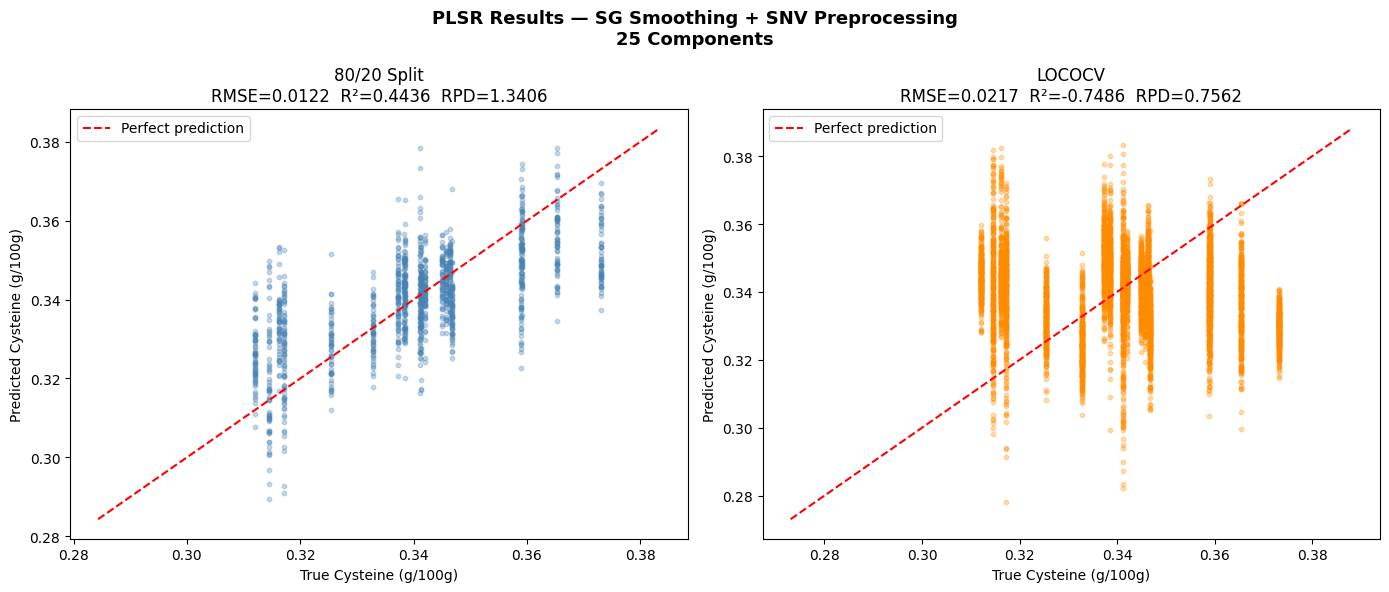

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel 1: 80/20 split ──
ax1 = axes[0]
ax1.scatter(y_test, y_pred_test, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test.min(), y_pred_test.min()) - 0.005
max_val = max(y_test.max(), y_pred_test.max()) + 0.005
ax1.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel("True Cysteine (g/100g)")
ax1.set_ylabel("Predicted Cysteine (g/100g)")
ax1.set_title(f"80/20 Split\nRMSE={rmse_test:.4f}  R²={r2_test:.4f}  RPD={rpd_test:.4f}")
ax1.legend()

# ── Panel 2: LOCOCV ──
ax2 = axes[1]
ax2.scatter(all_y_true, all_y_pred, alpha=0.3, s=10, color='darkorange')
min_val = min(all_y_true.min(), all_y_pred.min()) - 0.005
max_val = max(all_y_true.max(), all_y_pred.max()) + 0.005
ax2.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5, label='Perfect prediction')
ax2.set_xlabel("True Cysteine (g/100g)")
ax2.set_ylabel("Predicted Cysteine (g/100g)")
ax2.set_title(f"LOCOCV\nRMSE={global_rmse:.4f}  R²={global_r2:.4f}  RPD={global_rpd:.4f}")
ax2.legend()

plt.suptitle("PLSR Results — SG Smoothing + SNV Preprocessing\n25 Components",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("PLSR_results.png", dpi=150, bbox_inches='tight')
plt.show()

Find optimal number of components:

Components:  1  CV RMSE: 0.01613
Components:  2  CV RMSE: 0.01599
Components:  3  CV RMSE: 0.01577
Components:  4  CV RMSE: 0.01520
Components:  5  CV RMSE: 0.01489
Components:  6  CV RMSE: 0.01460
Components:  7  CV RMSE: 0.01438
Components:  8  CV RMSE: 0.01401
Components:  9  CV RMSE: 0.01380
Components: 10  CV RMSE: 0.01348
Components: 11  CV RMSE: 0.01314
Components: 12  CV RMSE: 0.01299
Components: 13  CV RMSE: 0.01287
Components: 14  CV RMSE: 0.01274
Components: 15  CV RMSE: 0.01267
Components: 16  CV RMSE: 0.01264
Components: 17  CV RMSE: 0.01260
Components: 18  CV RMSE: 0.01256
Components: 19  CV RMSE: 0.01256
Components: 20  CV RMSE: 0.01259
Components: 21  CV RMSE: 0.01264
Components: 22  CV RMSE: 0.01267
Components: 23  CV RMSE: 0.01270
Components: 24  CV RMSE: 0.01275
Components: 25  CV RMSE: 0.01281
Components: 26  CV RMSE: 0.01283
Components: 27  CV RMSE: 0.01287
Components: 28  CV RMSE: 0.01284
Components: 29  CV RMSE: 0.01285
Components: 30  CV RMSE: 0.01285
Components

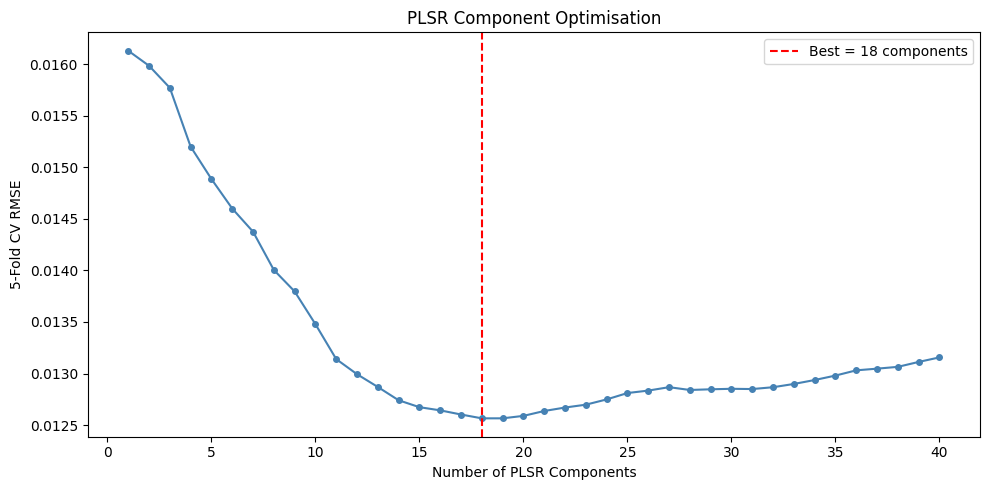

In [11]:
from sklearn.model_selection import cross_val_score

components_to_try = range(1, 41)
cv_rmse = []

for n in components_to_try:
    plsr_cv = PLSRegression(n_components=n)
    # Negative MSE scores, we convert to RMSE
    scores = cross_val_score(plsr_cv, X_train, y_train,
                             cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    cv_rmse.append(rmse)
    print(f"Components: {n:2d}  CV RMSE: {rmse:.5f}")

# Find best
best_n = components_to_try[np.argmin(cv_rmse)]
print(f"\nBest number of components: {best_n}")
print(f"Best CV RMSE: {min(cv_rmse):.5f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(components_to_try, cv_rmse, marker='o', markersize=4,
         color='steelblue', linewidth=1.5)
plt.axvline(best_n, color='red', linestyle='--',
            label=f'Best = {best_n} components')
plt.xlabel("Number of PLSR Components")
plt.ylabel("5-Fold CV RMSE")
plt.title("PLSR Component Optimisation")
plt.legend()
plt.tight_layout()
plt.savefig("PLSR_components.png", dpi=150)
plt.show()

Retrain with optimal 18 components:

In [12]:
best_n = 18

# ── 80/20 Split with optimal components ──
plsr_opt = PLSRegression(n_components=best_n)
plsr_opt.fit(X_train, y_train)

y_pred_train_opt = plsr_opt.predict(X_train).flatten()
y_pred_test_opt  = plsr_opt.predict(X_test).flatten()

rmse_train_opt = np.sqrt(mean_squared_error(y_train, y_pred_train_opt))
rmse_test_opt  = np.sqrt(mean_squared_error(y_test,  y_pred_test_opt))
r2_train_opt   = r2_score(y_train, y_pred_train_opt)
r2_test_opt    = r2_score(y_test,  y_pred_test_opt)
rpd_test_opt   = y_test.std() / rmse_test_opt

print("=== 80/20 Split — Optimised (18 components) ===")
print(f"Train RMSE: {rmse_train_opt:.4f}  R²: {r2_train_opt:.4f}")
print(f"Test  RMSE: {rmse_test_opt:.4f}  R²: {r2_test_opt:.4f}  RPD: {rpd_test_opt:.4f}")

# ── LOCOCV with optimal components ──
all_y_true_opt = []
all_y_pred_opt = []
loco_rmse_opt  = []

for held_out in cultivar_names:
    X_train_loco, y_train_loco = [], []
    X_test_loco,  y_test_loco  = [], []

    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        for rs, intens in spectra:
            intens_sg  = savitzky_golay_smooth(np.array([intens]))[0]
            intens_snv = snv(np.array([intens_sg]))[0]

            if folder_name == held_out:
                X_test_loco.append(intens_snv)
                y_test_loco.append(meta['cys'])
            else:
                X_train_loco.append(intens_snv)
                y_train_loco.append(meta['cys'])

    X_train_loco = np.array(X_train_loco)
    y_train_loco = np.array(y_train_loco)
    X_test_loco  = np.array(X_test_loco)
    y_test_loco  = np.array(y_test_loco)

    plsr_loco_opt = PLSRegression(n_components=best_n)
    plsr_loco_opt.fit(X_train_loco, y_train_loco)
    y_pred_loco = plsr_loco_opt.predict(X_test_loco).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_loco, y_pred_loco))
    loco_rmse_opt.append(rmse)
    all_y_true_opt.extend(y_test_loco)
    all_y_pred_opt.extend(y_pred_loco)

    print(f"{CULTIVARS[held_out]['label']:20s} → RMSE: {rmse:.4f}  "
          f"True: {y_test_loco[0]:.4f}  "
          f"Predicted mean: {np.mean(y_pred_loco):.4f}")

all_y_true_opt = np.array(all_y_true_opt)
all_y_pred_opt = np.array(all_y_pred_opt)

global_rmse_opt = np.sqrt(mean_squared_error(all_y_true_opt, all_y_pred_opt))
global_r2_opt   = r2_score(all_y_true_opt, all_y_pred_opt)
global_rpd_opt  = all_y_true_opt.std() / global_rmse_opt

print(f"\n=== LOCOCV — Optimised (18 components) ===")
print(f"Mean RMSE per fold: {np.mean(loco_rmse_opt):.4f}")
print(f"Global RMSE:        {global_rmse_opt:.4f}")
print(f"Global R²:          {global_r2_opt:.4f}")
print(f"Global RPD:         {global_rpd_opt:.4f}")

=== 80/20 Split — Optimised (18 components) ===
Train RMSE: 0.0115  R²: 0.5119
Test  RMSE: 0.0122  R²: 0.4476  RPD: 1.3455
AAC Chrome           → RMSE: 0.0261  True: 0.3172  Predicted mean: 0.3408
AAC Lacombe          → RMSE: 0.0102  True: 0.3386  Predicted mean: 0.3437
AAC Liscard          → RMSE: 0.0086  True: 0.3254  Predicted mean: 0.3307
CDC Amarillo         → RMSE: 0.0224  True: 0.3589  Predicted mean: 0.3386
CDC Athabasca        → RMSE: 0.0123  True: 0.3412  Predicted mean: 0.3409
CDC Canary           → RMSE: 0.0267  True: 0.3145  Predicted mean: 0.3368
CDC Dakota           → RMSE: 0.0107  True: 0.3328  Predicted mean: 0.3258
CDC Golden           → RMSE: 0.0191  True: 0.3591  Predicted mean: 0.3423
CDC Greenwater       → RMSE: 0.0076  True: 0.3464  Predicted mean: 0.3493
CDC Inca             → RMSE: 0.0293  True: 0.3653  Predicted mean: 0.3379
CDC Jasper           → RMSE: 0.0158  True: 0.3373  Predicted mean: 0.3505
CDC Lewochko         → RMSE: 0.0154  True: 0.3413  Predicted me

Final PLSR summary plot:

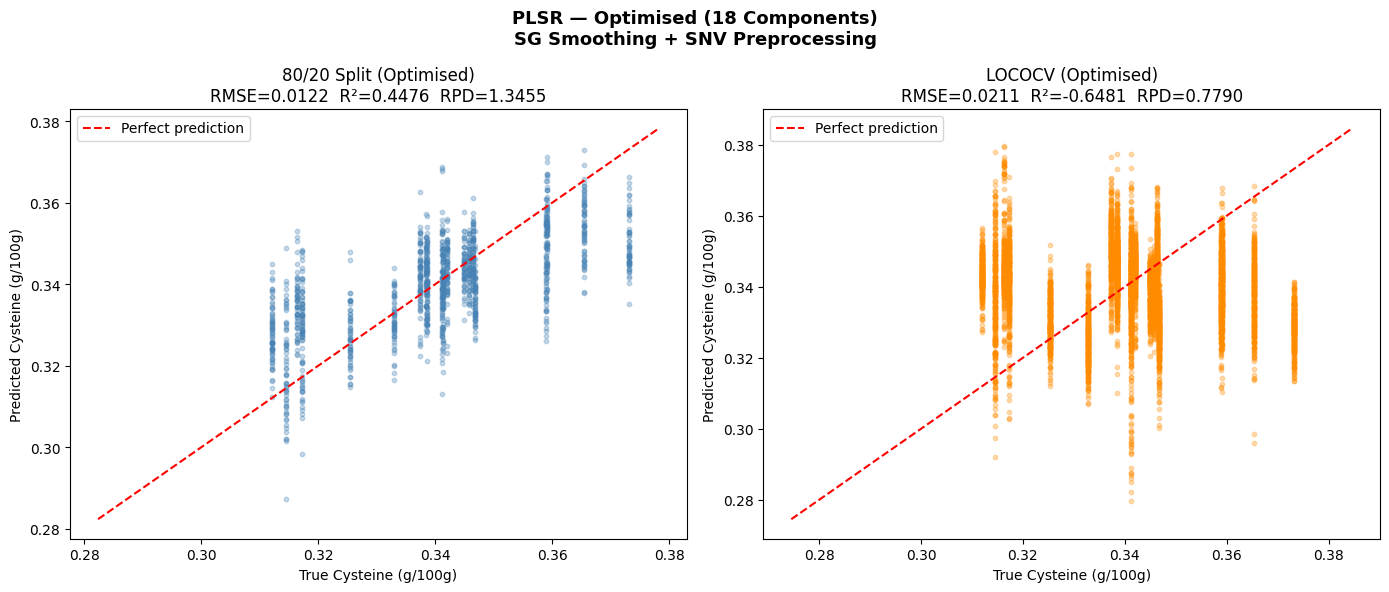


       PLSR FINAL RESULTS SUMMARY
Metric                   80/20 Split          LOCOCV
-------------------------------------------------------
RMSE                          0.0122          0.0211
R²                            0.4476         -0.6481
RPD                           1.3455          0.7790
Components                        18              18


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel 1: 80/20 split ──
ax1 = axes[0]
ax1.scatter(y_test, y_pred_test_opt, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test.min(), y_pred_test_opt.min()) - 0.005
max_val = max(y_test.max(), y_pred_test_opt.max()) + 0.005
ax1.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel("True Cysteine (g/100g)")
ax1.set_ylabel("Predicted Cysteine (g/100g)")
ax1.set_title(f"80/20 Split (Optimised)\n"
              f"RMSE={rmse_test_opt:.4f}  R²={r2_test_opt:.4f}  RPD={rpd_test_opt:.4f}")
ax1.legend()

# ── Panel 2: LOCOCV ──
ax2 = axes[1]
ax2.scatter(all_y_true_opt, all_y_pred_opt, alpha=0.3, s=10, color='darkorange')
min_val = min(all_y_true_opt.min(), all_y_pred_opt.min()) - 0.005
max_val = max(all_y_true_opt.max(), all_y_pred_opt.max()) + 0.005
ax2.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5, label='Perfect prediction')
ax2.set_xlabel("True Cysteine (g/100g)")
ax2.set_ylabel("Predicted Cysteine (g/100g)")
ax2.set_title(f"LOCOCV (Optimised)\n"
              f"RMSE={global_rmse_opt:.4f}  R²={global_r2_opt:.4f}  RPD={global_rpd_opt:.4f}")
ax2.legend()

plt.suptitle("PLSR — Optimised (18 Components)\nSG Smoothing + SNV Preprocessing",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("PLSR_optimised_results.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Print final summary table ──
print("\n" + "="*55)
print("       PLSR FINAL RESULTS SUMMARY")
print("="*55)
print(f"{'Metric':<20} {'80/20 Split':>15} {'LOCOCV':>15}")
print("-"*55)
print(f"{'RMSE':<20} {rmse_test_opt:>15.4f} {global_rmse_opt:>15.4f}")
print(f"{'R²':<20} {r2_test_opt:>15.4f} {global_r2_opt:>15.4f}")
print(f"{'RPD':<20} {rpd_test_opt:>15.4f} {global_rpd_opt:>15.4f}")
print(f"{'Components':<20} {best_n:>15} {best_n:>15}")
print("="*55)

Define all preprocessing combinations:

In [14]:
from scipy.signal import savgol_filter

def msc(X):
    """Multiplicative Scatter Correction"""
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

# Define all combinations to test
preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Total combinations to test: {len(preprocessing_combos)}")

Total combinations to test: 8


Run all preprocessing combinations:

In [15]:
results_summary = []

for combo_name, preprocess_fn in preprocessing_combos.items():
    print(f"\nTesting: {combo_name}")

    # Apply preprocessing to full dataset
    try:
        X_combo = preprocess_fn(X)
    except Exception as e:
        print(f" Failed: {e}")
        continue

    # ── 80/20 Split ──
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_combo, y, test_size=0.2, random_state=42
    )

    # Find best components (search 1-30)
    best_rmse_cv = np.inf
    best_n_cv    = 1
    for n in range(1, 31):
        plsr_tmp = PLSRegression(n_components=n)
        scores   = cross_val_score(plsr_tmp, X_tr, y_tr,
                                   cv=5, scoring='neg_mean_squared_error')
        rmse_cv  = np.sqrt(-scores.mean())
        if rmse_cv < best_rmse_cv:
            best_rmse_cv = rmse_cv
            best_n_cv    = n

    # Train with best components
    plsr_combo = PLSRegression(n_components=best_n_cv)
    plsr_combo.fit(X_tr, y_tr)
    y_pred_te  = plsr_combo.predict(X_te).flatten()

    rmse_8020 = np.sqrt(mean_squared_error(y_te, y_pred_te))
    r2_8020   = r2_score(y_te, y_pred_te)
    rpd_8020  = y_te.std() / rmse_8020

    print(f"  Best components: {best_n_cv}")
    print(f"  80/20 → RMSE: {rmse_8020:.4f}  R²: {r2_8020:.4f}  RPD: {rpd_8020:.4f}")

    # ── LOCOCV ──
    all_true, all_pred = [], []

    for held_out in cultivar_names:
        X_tr_l, y_tr_l = [], []
        X_te_l, y_te_l = [], []

        for folder_name, meta in CULTIVARS.items():
            spectra = all_data.get(folder_name, [])
            for rs, intens in spectra:
                arr = np.array([intens])
                arr_pre = preprocess_fn(arr)[0]
                if folder_name == held_out:
                    X_te_l.append(arr_pre)
                    y_te_l.append(meta['cys'])
                else:
                    X_tr_l.append(arr_pre)
                    y_tr_l.append(meta['cys'])

        plsr_l = PLSRegression(n_components=best_n_cv)
        plsr_l.fit(np.array(X_tr_l), np.array(y_tr_l))
        y_pred_l = plsr_l.predict(np.array(X_te_l)).flatten()

        all_true.extend(y_te_l)
        all_pred.extend(y_pred_l)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse_loco = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_loco   = r2_score(all_true, all_pred)
    rpd_loco  = all_true.std() / rmse_loco

    print(f"  LOCO  → RMSE: {rmse_loco:.4f}  R²: {r2_loco:.4f}  RPD: {rpd_loco:.4f}")

    results_summary.append({
        "Preprocessing":  combo_name,
        "Best_n":         best_n_cv,
        "RMSE_8020":      rmse_8020,
        "R2_8020":        r2_8020,
        "RPD_8020":       rpd_8020,
        "RMSE_LOCO":      rmse_loco,
        "R2_LOCO":        r2_loco,
        "RPD_LOCO":       rpd_loco,
    })

print("\nAll combinations done!")


Testing: SG + SNV
  Best components: 18
  80/20 → RMSE: 0.0122  R²: 0.4476  RPD: 1.3455
  LOCO  → RMSE: 0.0211  R²: -0.6481  RPD: 0.7790

Testing: SG + MSC
  Best components: 18
  80/20 → RMSE: 0.0125  R²: 0.4182  RPD: 1.3111
  LOCO  → RMSE: 0.0236  R²: -1.0547  RPD: 0.6976

Testing: SG + 1st Deriv
  Best components: 30
  80/20 → RMSE: 0.0139  R²: 0.2811  RPD: 1.1794
  LOCO  → RMSE: 0.0238  R²: -1.0987  RPD: 0.6903

Testing: SG + 2nd Deriv
  Best components: 25
  80/20 → RMSE: 0.0140  R²: 0.2730  RPD: 1.1729
  LOCO  → RMSE: 0.0223  R²: -0.8413  RPD: 0.7369

Testing: SG + SNV + 1st Der
  Best components: 30
  80/20 → RMSE: 0.0122  R²: 0.4470  RPD: 1.3447
  LOCO  → RMSE: 0.0217  R²: -0.7433  RPD: 0.7574

Testing: SG + SNV + 2nd Der
  Best components: 30
  80/20 → RMSE: 0.0127  R²: 0.3989  RPD: 1.2898
  LOCO  → RMSE: 0.0219  R²: -0.7762  RPD: 0.7503

Testing: SG + MSC + 1st Der
  Best components: 28
  80/20 → RMSE: 0.0125  R²: 0.4154  RPD: 1.3079
  LOCO  → RMSE: 0.0238  R²: -1.0876  RPD:

Results comparison table and plot:

         PLSR PREPROCESSING COMPARISON RESULTS
Preprocessing             n  RMSE_8020  R2_8020  RPD_8020  RMSE_LOCO   R2_LOCO  RPD_LOCO
-------------------------------------------------------------------------------------
SG + SNV                 18     0.0122   0.4476    1.3455     0.0211   -0.6481    0.7790
SG + MSC                 18     0.0125   0.4182    1.3111     0.0236   -1.0547    0.6976
SG + 1st Deriv           30     0.0139   0.2811    1.1794     0.0238   -1.0987    0.6903
SG + 2nd Deriv           25     0.0140   0.2730    1.1729     0.0223   -0.8413    0.7369
SG + SNV + 1st Der       30     0.0122   0.4470    1.3447     0.0217   -0.7433    0.7574
SG + SNV + 2nd Der       30     0.0127   0.3989    1.2898     0.0219   -0.7762    0.7503
SG + MSC + 1st Der       28     0.0125   0.4154    1.3079     0.0238   -1.0876    0.6921
SG + MSC + 2nd Der       27     0.0129   0.3832    1.2733     0.0225   -0.8643    0.7324

Best 80/20 preprocessing: SG + SNV
Best LOCO  preprocessing: SG +

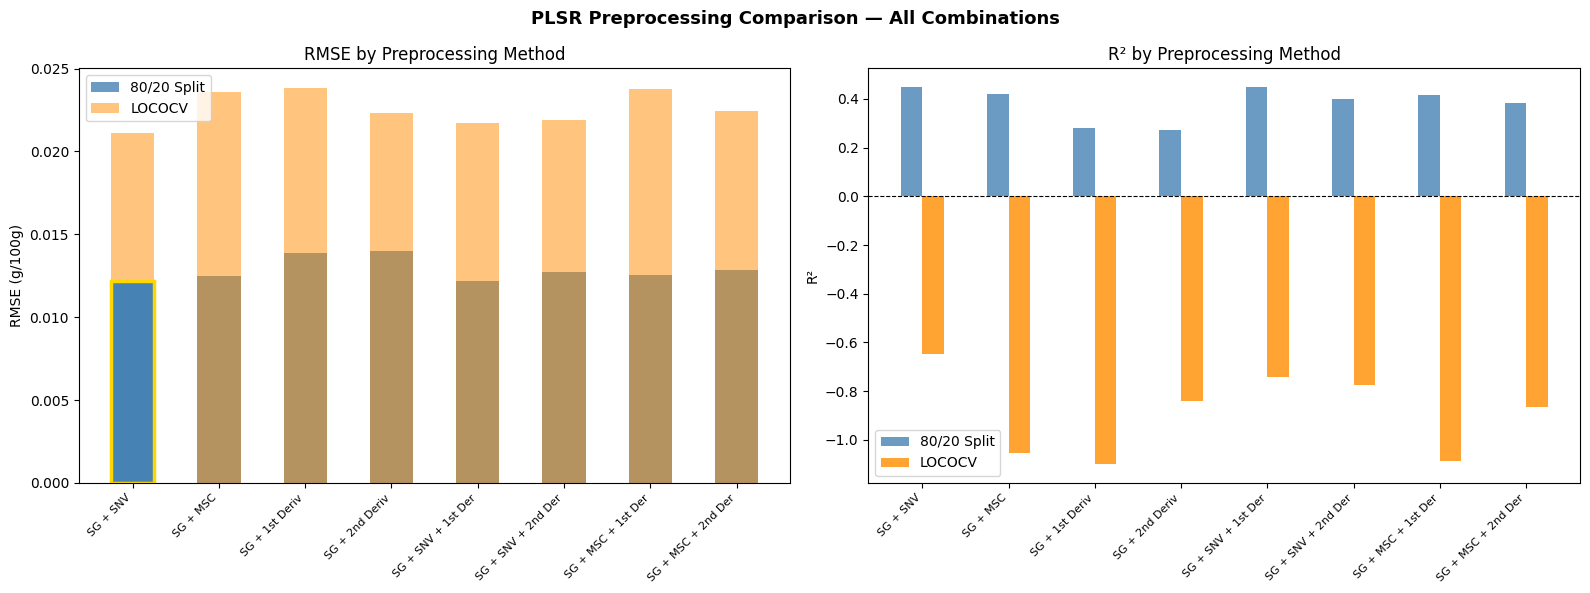

In [16]:
import pandas as pd

# Create results dataframe
df = pd.DataFrame(results_summary)

print("="*85)
print("         PLSR PREPROCESSING COMPARISON RESULTS")
print("="*85)
print(f"{'Preprocessing':<22} {'n':>4} {'RMSE_8020':>10} {'R2_8020':>8} {'RPD_8020':>9} {'RMSE_LOCO':>10} {'R2_LOCO':>9} {'RPD_LOCO':>9}")
print("-"*85)
for _, row in df.iterrows():
    print(f"{row['Preprocessing']:<22} {int(row['Best_n']):>4} "
          f"{row['RMSE_8020']:>10.4f} {row['R2_8020']:>8.4f} {row['RPD_8020']:>9.4f} "
          f"{row['RMSE_LOCO']:>10.4f} {row['R2_LOCO']:>9.4f} {row['RPD_LOCO']:>9.4f}")
print("="*85)

# Highlight best
best_8020 = df.loc[df['RMSE_8020'].idxmin(), 'Preprocessing']
best_loco  = df.loc[df['RMSE_LOCO'].idxmin(), 'Preprocessing']
print(f"\nBest 80/20 preprocessing: {best_8020}")
print(f"Best LOCO  preprocessing: {best_loco}")

# ── Plot comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = [r['Preprocessing'] for r in results_summary]
x = np.arange(len(labels))
width = 0.5

# Panel 1: RMSE comparison
ax1 = axes[0]
bars1 = ax1.bar(x, df['RMSE_8020'], width, 
                color='steelblue', alpha=0.8, label='80/20 Split')
bars2 = ax1.bar(x, df['RMSE_LOCO'], width,
                color='darkorange', alpha=0.5, label='LOCOCV')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel("RMSE (g/100g)")
ax1.set_title("RMSE by Preprocessing Method")
ax1.legend()
# Annotate best
ax1.bar(df['RMSE_8020'].idxmin(), df['RMSE_8020'].min(),
        width, color='steelblue', alpha=1.0, edgecolor='gold',
        linewidth=2.5)

# Panel 2: R² comparison
ax2 = axes[1]
ax2.bar(x - width/4, df['R2_8020'], width/2,
        color='steelblue', alpha=0.8, label='80/20 Split')
ax2.bar(x + width/4, df['R2_LOCO'], width/2,
        color='darkorange', alpha=0.8, label='LOCOCV')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel("R²")
ax2.set_title("R² by Preprocessing Method")
ax2.legend()

plt.suptitle("PLSR Preprocessing Comparison — All Combinations",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("PLSR_preprocessing_comparison.png", dpi=150, bbox_inches='tight')
plt.show()